Log Transformation

In [94]:
import pandas as pd
import numpy as np

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import r2_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [95]:
titanic = pd.read_csv("train.csv")

In [96]:
titanic.head(1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S


In [97]:
titanic.drop(columns = ['PassengerId', 'Pclass', 'Name', 'Embarked', 'Cabin', 'SibSp', 'Parch', 'Ticket'], inplace = True)

In [98]:
titanic['Age'].fillna(titanic['Age'].mean(), inplace = True)

C:\Users\Pranav Wadatkar\AppData\Local\Temp\ipykernel_21892\2090679368.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  titanic['Age'].fillna(titanic['Age'].mean(), inplace = True)


0      22.000000
1      38.000000
2      26.000000
3      35.000000
4      35.000000
         ...    
886    27.000000
887    19.000000
888    29.699118
889    26.000000
890    32.000000
Name: Age, Length: 891, dtype: float64

In [99]:
titanic.head()

,Survived,Sex,Age,Fare
0,0,male,22.0,7.2500
1,1,female,38.0,71.2833
2,1,female,26.0,7.9250
3,1,female,35.0,53.1000
4,0,male,35.0,8.0500


In [100]:
x = titanic.iloc[:,1:4]
y = titanic.iloc[:,0]

In [101]:
x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    test_size=0.2,
                                                    random_state=42)

C:\Users\Pranav Wadatkar\AppData\Local\Temp\ipykernel_21892\2487713103.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Age'])


Text(0.5, 1.0, 'Age QQ Plot')

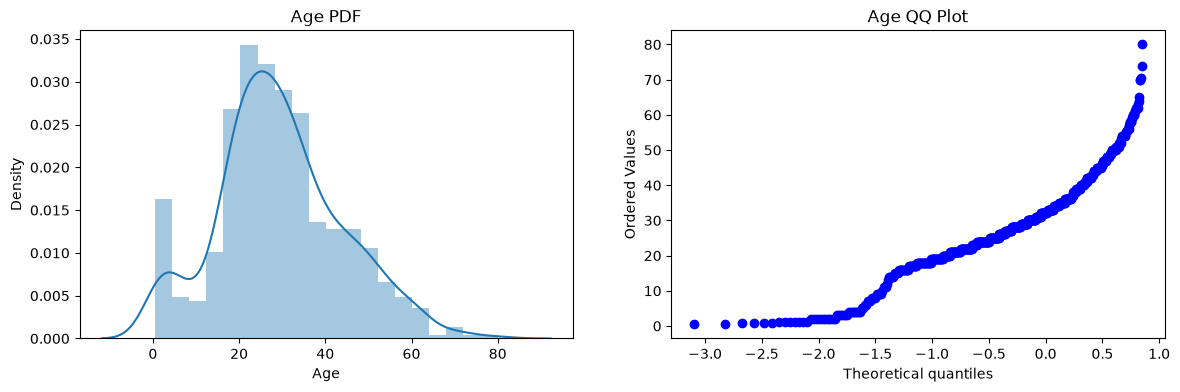

In [102]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(x_train['Age'])
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(x_train['Age'], dist="norm", plot=plt)
plt.title('Age QQ Plot')


C:\Users\Pranav Wadatkar\AppData\Local\Temp\ipykernel_21892\4019500073.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Fare'])


Text(0.5, 1.0, 'Fare QQ Plot')

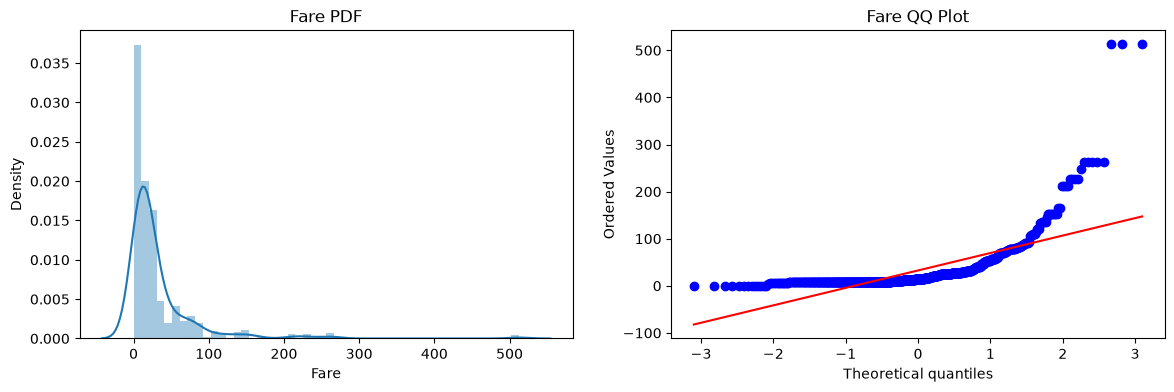

In [103]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(x_train['Fare'])
plt.title('Fare PDF')

plt.subplot(122)
stats.probplot(x_train['Fare'], dist="norm", plot=plt)
plt.title('Fare QQ Plot')

In [104]:
ohe_sex = OneHotEncoder(sparse_output=False,handle_unknown="ignore")

x_train_sex = ohe_sex.fit_transform(x_train[["Sex"]])
x_test_sex = ohe_sex.transform(x_test[["Sex"]])

In [105]:
si_age = SimpleImputer(strategy="mean")

x_train_age = si_age.fit_transform(x_train[["Age"]])
x_test_age = si_age.transform(x_test[["Age"]])

In [106]:
x_train_fare = x_train[["Fare"]].values
x_test_fare = x_test[["Fare"]].values

In [107]:
x_train_transformed = np.concatenate(
    (x_train_sex, x_train_age, x_train_fare),
    axis=1
)

x_test_transformed = np.concatenate(
    (x_test_sex, x_test_age, x_test_fare),
    axis=1
)

In [108]:
lr = LogisticRegression()
clf = DecisionTreeClassifier()

In [116]:
lr.fit(x_train_transformed, y_train)
clf.fit(x_train_transformed, y_train)

y_pred_lr = lr.predict(x_test_transformed)
y_pred_clf = clf.predict(x_test_transformed)

print("Accuracy lr: ", accuracy_score(y_test, y_pred_lr))
print("Accuracy clf: ", accuracy_score(y_pred_clf,y_test))

Accuracy lr:  0.776536312849162
Accuracy clf:  0.776536312849162


In [110]:
trf = FunctionTransformer(func=np.log1p)

In [111]:
x_train_ftransformed = trf.fit_transform(x_train_transformed)
x_test_ftransformed = trf.fit_transform(x_test_transformed)

In [115]:
lr.fit(x_train_ftransformed, y_train)
clf.fit(x_train_ftransformed, y_train)

y_pred_lr = lr.predict(x_test_ftransformed)
y_pred_clf = clf.predict(x_test_ftransformed)

print("Accuracy lr: ", accuracy_score(y_test, y_pred_lr))
print("Accuracy clf: ", accuracy_score(y_pred_clf,y_test))

Accuracy lr:  0.7821229050279329
Accuracy clf:  0.7821229050279329


In [119]:
x_transformed = trf.fit_transform(x)

lr2 = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR", np.mean(cross_val_score(lr2, x_transformed, y_train, scoring='accuracy', cv=10)))
print("DT", np.mean(cross_val_score(clf2, x_transformed, y_train, scoring='accuracy', cv=10)))

TypeError: loop of ufunc does not support argument 0 of type str which has no callable log1p method